In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("arashnic/faces-age-detection-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'faces-age-detection-dataset' dataset.
Path to dataset files: /kaggle/input/faces-age-detection-dataset


In [3]:
import os

dataset_path = "/root/.cache/kagglehub/datasets/arashnic/faces-age-detection-dataset/versions/2"

for root, dirs, files in os.walk(dataset_path):
    print("Folder:", root)
    print("Subfolders:", dirs)
    print("Files:", files[:5])
    print("-" * 50)

In [4]:
import pandas as pd
import os

train_csv_path = os.path.join(path, "faces", "train.csv")
df = pd.read_csv(train_csv_path)
df.head()

,ID,Class
0,377.jpg,MIDDLE
1,17814.jpg,YOUNG
2,21283.jpg,MIDDLE
3,16496.jpg,YOUNG
4,4487.jpg,MIDDLE


In [5]:
print("Total:", len(df))


Total: 19906


In [6]:
df["Class"].value_counts()

,count
Class,
MIDDLE,10804
YOUNG,6706
OLD,2396


In [7]:
print("\nClass percentage:")
print(df["Class"].value_counts(normalize=True) * 100)


Class percentage:
Class
MIDDLE    54.275093
YOUNG     33.688335
OLD       12.036572
Name: proportion, dtype: float64


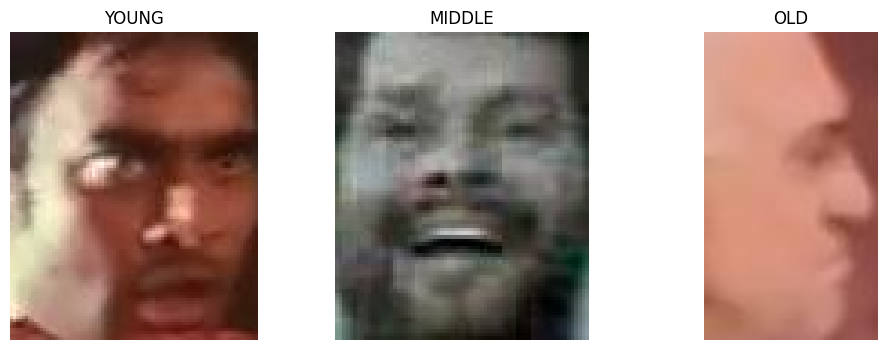

In [8]:
import matplotlib.pyplot as plt
from PIL import Image
import os

# Construct the correct path to the Train images directory using the 'path' variable
image_dir = os.path.join(path, "faces", "Train")

classes = ["YOUNG", "MIDDLE", "OLD"]

plt.figure(figsize=(12, 4))

for i, class_name in enumerate(classes):
    row = df[df["Class"] == class_name].iloc[0]
    image_path = os.path.join(image_dir, row["ID"])

    image = Image.open(image_path)

    plt.subplot(1, 3, i + 1)
    plt.imshow(image)
    plt.title(class_name)
    plt.axis("off")

plt.show()

In [9]:
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import pandas as pd
import os

In [10]:
image_dir = os.path.join(path, "faces", "Train")
data = df.copy()

In [11]:
class_to_idx = {
    "YOUNG": 0,
    "MIDDLE": 1,
    "OLD": 2
}

data["label"] = data["Class"].map(class_to_idx)
print(data.head())

          ID   Class  label
0    377.jpg  MIDDLE      1
1  17814.jpg   YOUNG      0
2  21283.jpg  MIDDLE      1
3  16496.jpg   YOUNG      0
4   4487.jpg  MIDDLE      1


In [12]:
from sklearn.model_selection import train_test_split

In [13]:
train_df, val_df = train_test_split(
    data,
    test_size=0.2,
    random_state=42,
    stratify=data["label"]
)

print("Training samples:", len(train_df))
print("Validation samples:", len(val_df))

Training samples: 15924
Validation samples: 3982


In [14]:
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [15]:
class AgeDataset(Dataset):
    def __init__(self, dataframe, image_dir, transform=None):
        # Fixed typo: rest_index -> reset_index
        self.dataframe = dataframe.reset_index(drop=True)
        self.image_dir = image_dir
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        row = self.dataframe.iloc[idx]
        image_path = os.path.join(self.image_dir, row["ID"])
        image = Image.open(image_path).convert("RGB")

        label = row["label"]

        if self.transform:
            image = self.transform(image)

        return image, torch.tensor(label, dtype=torch.long)

train_dataset = AgeDataset(train_df, image_dir, transform=train_transform)
val_dataset = AgeDataset(val_df, image_dir, transform=val_transform)

In [16]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

In [17]:
images, labels = next(iter(train_loader))

print("Image shape:", images.shape)
print("Labels shape:", labels.shape)
print("Labels:", labels[:10])

Image shape: torch.Size([32, 3, 224, 224])
Labels shape: torch.Size([32])
Labels: tensor([0, 0, 0, 0, 0, 1, 0, 1, 2, 0])


In [18]:
import torch.nn as nn
class AgeCNN(nn.Module):
    def __init__(self):
        super(AgeCNN, self).__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Conv2d(128, 256, kernel_size=3, stride=1, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Conv2d(256, 512, kernel_size=3, stride=1, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Conv2d(512, 512, kernel_size=3, stride=1, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),

        )
        self.classifier = nn.Sequential(
            nn.Dropout(),
            nn.Linear(512 * 7 * 7, 4096),
            nn.ReLU(inplace=True),
            nn.Dropout(),
            nn.Linear(4096, 4096),
            nn.ReLU(inplace=True),
            nn.Linear(4096, 3),
        )

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        x = self.classifier(x)
        return x



In [19]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = AgeCNN().to(device)

print(model)
print("Device:", device)

AgeCNN(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU(inplace=True)
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU(inplace=True)
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (9): Conv2d(256, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (10): ReLU(inplace=True)
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): Conv2d(512, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): 

In [20]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)

Device: cuda


In [21]:
model = model.to(device)

In [22]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.0001
)

print("Loss function:", criterion)
print("Optimizer:", optimizer)

Loss function: CrossEntropyLoss()
Optimizer: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.0001
    maximize: False
    weight_decay: 0
)


In [23]:
print(device)

cuda


In [24]:
import torch

print("CUDA available:", torch.cuda.is_available())
print("Device:", torch.device("cuda" if torch.cuda.is_available() else "cpu"))

CUDA available: True
Device: cuda


In [25]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = AgeCNN().to(device)

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.0001
)

print("Device:", device)

Device: cuda


In [1]:
import torch

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("GPU is not available")

PyTorch version: 2.11.0+cu128
CUDA available: True
GPU: Tesla T4


In [26]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = model.to(device)

print("Device:", device)

Device: cuda


In [27]:
num_epochs = 10

train_losses = []
val_losses = []

train_accuracies = []
val_accuracies = []

for epoch in range(num_epochs):

    # =========================
    # Training
    # =========================
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    train_loss = running_loss / len(train_loader)
    train_accuracy = 100 * correct / total

    # =========================
    # Validation
    # =========================
    model.eval()

    val_running_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            val_running_loss += loss.item()

            _, predicted = torch.max(outputs, 1)

            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

    val_loss = val_running_loss / len(val_loader)
    val_accuracy = 100 * val_correct / val_total

    # Save metrics
    train_losses.append(train_loss)
    val_losses.append(val_loss)

    train_accuracies.append(train_accuracy)
    val_accuracies.append(val_accuracy)

    print(
        f"Epoch [{epoch+1}/{num_epochs}] | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_accuracy:.2f}% | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_accuracy:.2f}%"
    )

Epoch [1/10] | Train Loss: 0.8433 | Train Acc: 61.99% | Val Loss: 0.7574 | Val Acc: 67.73%
Epoch [2/10] | Train Loss: 0.7228 | Train Acc: 68.80% | Val Loss: 0.6751 | Val Acc: 70.99%
Epoch [3/10] | Train Loss: 0.6509 | Train Acc: 72.43% | Val Loss: 0.6322 | Val Acc: 73.13%
Epoch [4/10] | Train Loss: 0.6138 | Train Acc: 74.18% | Val Loss: 0.5895 | Val Acc: 75.16%
Epoch [5/10] | Train Loss: 0.5727 | Train Acc: 75.43% | Val Loss: 0.6358 | Val Acc: 73.81%
Epoch [6/10] | Train Loss: 0.5398 | Train Acc: 77.49% | Val Loss: 0.5609 | Val Acc: 76.95%
Epoch [7/10] | Train Loss: 0.5055 | Train Acc: 79.27% | Val Loss: 0.5595 | Val Acc: 76.70%
Epoch [8/10] | Train Loss: 0.4696 | Train Acc: 80.53% | Val Loss: 0.5100 | Val Acc: 78.96%
Epoch [9/10] | Train Loss: 0.4411 | Train Acc: 81.83% | Val Loss: 0.4974 | Val Acc: 79.86%
Epoch [10/10] | Train Loss: 0.4123 | Train Acc: 83.43% | Val Loss: 0.5321 | Val Acc: 79.58%


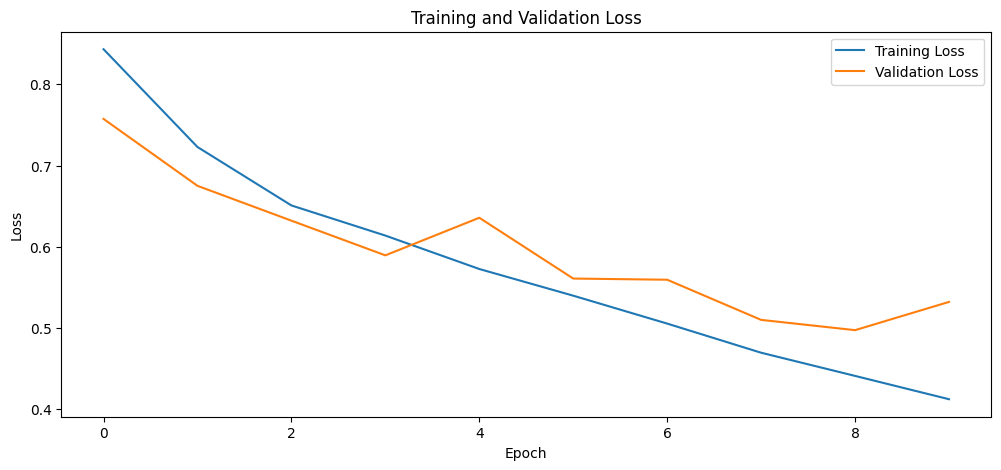

In [28]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.plot(train_losses, label="Training Loss")
plt.plot(val_losses, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.show()

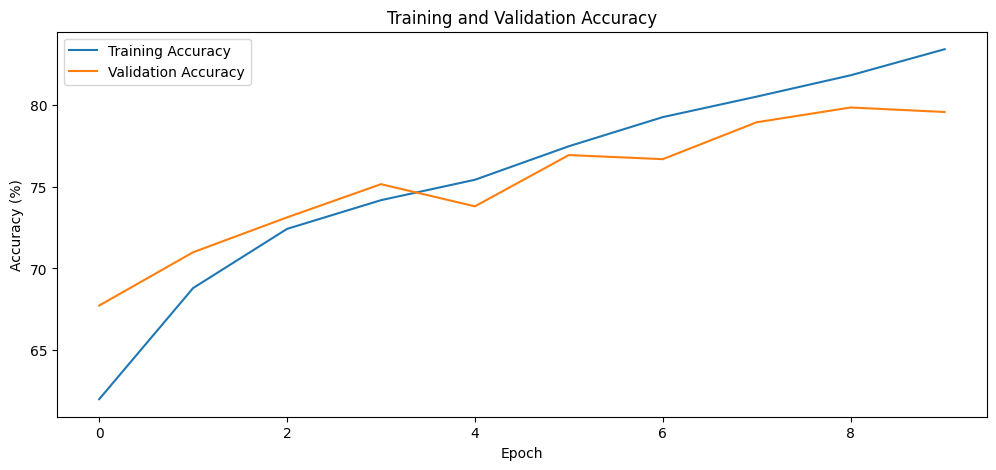

In [29]:
plt.figure(figsize=(12, 5))

plt.plot(train_accuracies, label="Training Accuracy")
plt.plot(val_accuracies, label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Training and Validation Accuracy")
plt.legend()
plt.show()

In [31]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

model.eval()

all_labels = []
all_predictions = []

with torch.no_grad():

    for images, labels in val_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        _, predictions = torch.max(outputs, 1)

        all_labels.extend(labels.cpu().numpy())
        all_predictions.extend(predictions.cpu().numpy())

all_labels = np.array(all_labels)
all_predictions = np.array(all_predictions)

print("Predictions completed!")

Predictions completed!


In [32]:
class_names = ["YOUNG", "MIDDLE", "OLD"]

print(
    classification_report(
        all_labels,
        all_predictions,
        target_names=class_names
    )
)

              precision    recall  f1-score   support

       YOUNG       0.87      0.69      0.77      1342
      MIDDLE       0.76      0.94      0.84      2161
         OLD       0.84      0.45      0.59       479

    accuracy                           0.80      3982
   macro avg       0.82      0.69      0.73      3982
weighted avg       0.81      0.80      0.79      3982



In [33]:
cm = confusion_matrix(
    all_labels,
    all_predictions
)

print(cm)

[[ 931  398   13]
 [ 112 2021   28]
 [  28  234  217]]


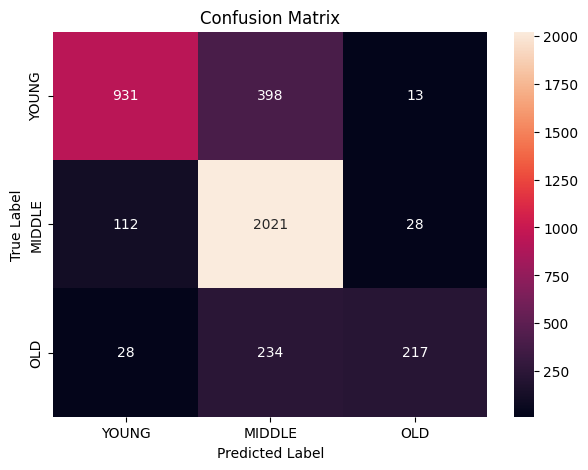

In [34]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()